# Edge Detection in Image Processing — Student Workbook

This notebook teaches four important edge detection methods in a simple way:

1. **Basic image gradients**
2. **Sobel operator**
3. **Laplacian operator**
4. **Canny edge detector**

Each topic contains:

- a short explanation
- a simple code example
- what to observe
- student exercises
- a more challenging task

The examples start with **synthetic images** because they are easier to understand than real photographs.  
After that, students can try the same methods on their own images.

## Learning goals

By the end of this notebook, students should be able to:

- explain what an edge is in an image
- describe how intensity changes create edges
- apply gradient-based edge detection
- compare Sobel, Laplacian, and Canny
- choose a suitable detector for a given problem
- tune parameters and justify their choices

## 0. Setup

This cell imports the required libraries and defines a helper function for plotting images.

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("C:/Users/sudob/OneDrive/Desktop/week7/bear.jpg")

def show(img, title="", cmap="gray", size=(5,5)):
    plt.figure(figsize=size)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

## 1. Create simple images for learning

We first create very simple black-and-white images.  
This helps us understand clearly where edges exist.

- A **square** has straight vertical and horizontal edges.
- A **circle** has curved edges.
- A **step image** has one sudden intensity change.

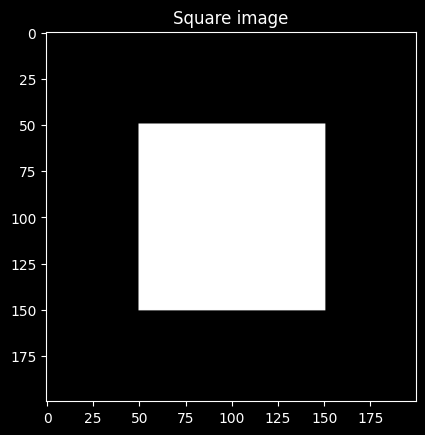

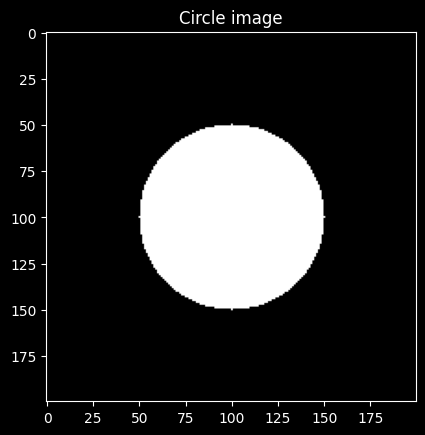

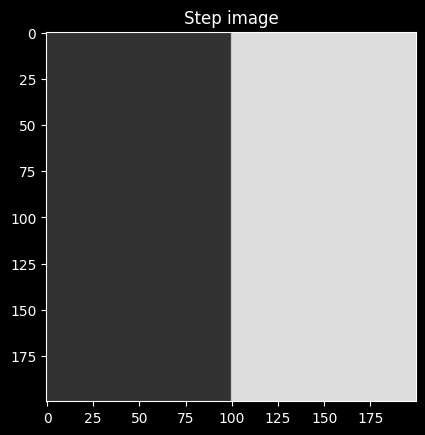

In [28]:
# Black background

img_square = np.zeros((200, 200), dtype=np.uint8)
img_circle = np.zeros((200, 200), dtype=np.uint8)
img_step = np.zeros((200, 200), dtype=np.uint8)

# Draw shapes
cv2.rectangle(img_square, (50, 50), (150, 150), 255, -1)
cv2.circle(img_circle, (100, 100), 50, 255, -1)

# Create a step image: left side dark, right side bright
img_step[:, :100] = 50
img_step[:, 100:] = 220
plt.imshow(cv2.cvtColor(img_square, cv2.COLOR_BGR2RGB))
plt.title("Square image")
plt.show()

plt.imshow(cv2.cvtColor(img_circle, cv2.COLOR_BGR2RGB))
plt.title("Circle image")
plt.show()

plt.imshow(cv2.cvtColor(img_step, cv2.COLOR_BGR2RGB))
plt.title("Step image")
plt.show()

## 2. Topic 1 — Simple image gradients

### Main idea

An edge appears where pixel intensity changes quickly.

A very simple way to detect this is to subtract neighbouring pixels.  
This is called a **gradient**.

For example, a horizontal gradient kernel can be:

`[-1, 1]`

This kernel checks how much the intensity changes from one pixel to the next.

### What this means

- If two neighbouring pixels are similar, the output is close to **0**
- If the intensity changes suddenly, the output becomes **large**
- Positive and negative values show the **direction** of change

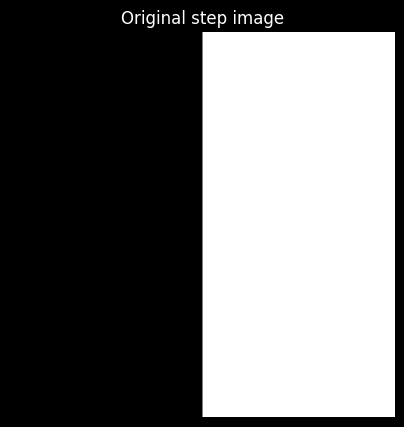

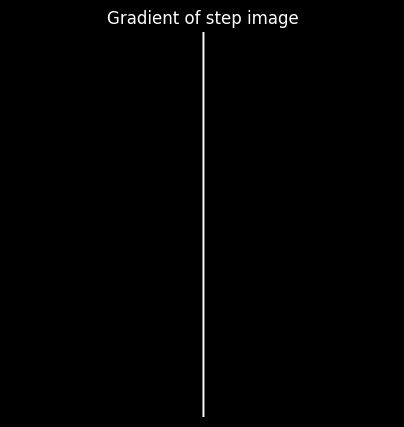

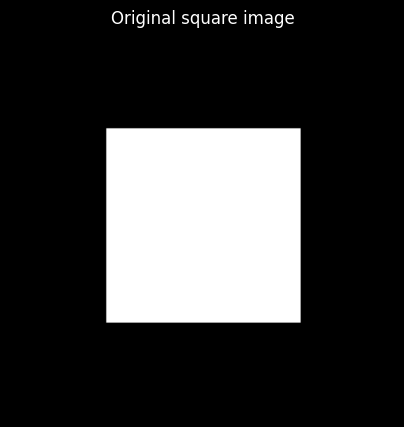

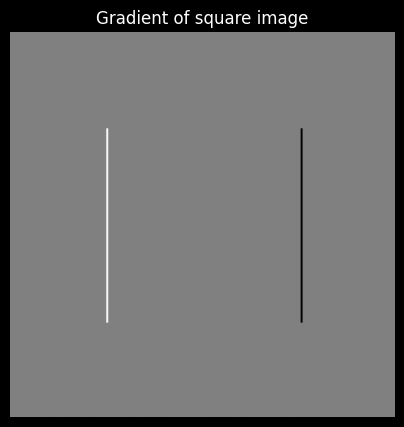

In [29]:
# Simple horizontal gradient kernel
kernel_x = np.array([[-1, 1]], dtype=np.float32)

grad_step = cv2.filter2D(img_step, cv2.CV_64F, kernel_x)
grad_square = cv2.filter2D(img_square, cv2.CV_64F, kernel_x)

show(img_step, "Original step image")
show(grad_step, "Gradient of step image")
show(img_square, "Original square image")
show(grad_square, "Gradient of square image")

### Why do we use `CV_64F` here?

Gradient results can be **negative** or **positive**.

If we use an 8-bit image type directly:
- negative values may be clipped or lost
- some edge information disappears

So we first calculate in a signed / floating-point format such as `CV_64F`.

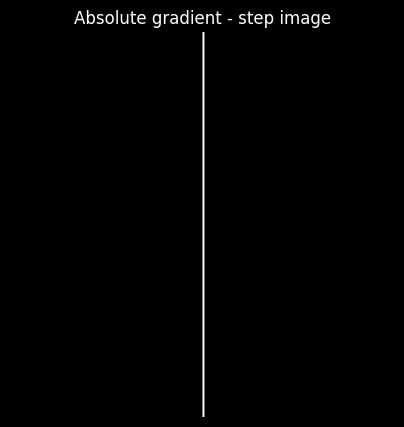

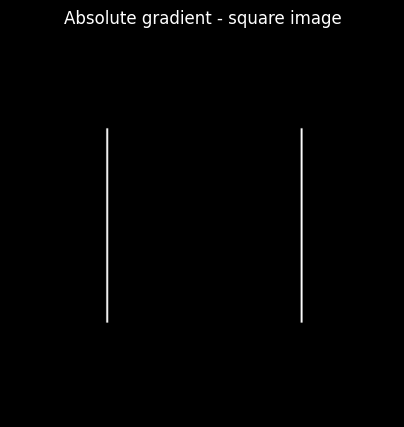

In [30]:
# Convert the gradient to absolute values for easier display
grad_square_abs = np.abs(grad_square).astype(np.uint8)
grad_step_abs = np.abs(grad_step).astype(np.uint8)

show(grad_step_abs, "Absolute gradient - step image")
show(grad_square_abs, "Absolute gradient - square image")

### What to observe

- In the **step image**, the strong response appears at the boundary between dark and bright regions.
- In the **square image**, the horizontal gradient mainly detects the **vertical edges**.
- The detector responds strongly where intensity changes along the x-direction.

### Student tasks — Topic 1

#### Basic tasks
1. Change the square position and observe how the detected edge location changes.
2. Create a brighter or darker square and compare the gradient strength.
3. Replace the square with a white rectangle of a different size.

#### Intermediate tasks
4. Create a **vertical gradient kernel** using:
   ```python
   kernel_y = np.array([[-1], [1]], dtype=np.float32)
   ```
   Apply it to the square image and compare the result with the horizontal gradient.
5. Apply both horizontal and vertical kernels to the circle image. Which one gives a stronger response at different parts of the circle?
6. Add a small amount of random noise to the image and test whether the gradient becomes unstable.

#### Challenging tasks
7. Build your own function called `simple_gradient(image, direction='x')` that computes either the horizontal or vertical gradient.
8. Combine x-gradient and y-gradient into one result using:
   ```python
   magnitude = np.sqrt(gx**2 + gy**2)
   ```
   Explain why this gives a more complete edge map.
9. Write a short paragraph explaining:
   - what an edge is,
   - why gradients detect edges,
   - and why absolute values are often used for display.

## 3. Topic 2 — Sobel edge detector

### Main idea

The Sobel operator is an improved gradient method.

Instead of using a very small kernel like `[-1, 1]`, Sobel uses a larger kernel that:
- detects intensity change
- also performs a small smoothing effect

This makes Sobel more stable than a very basic gradient operator.

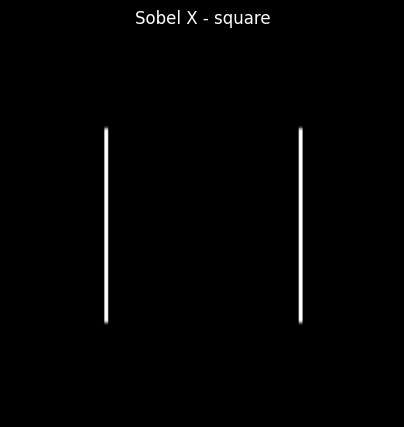

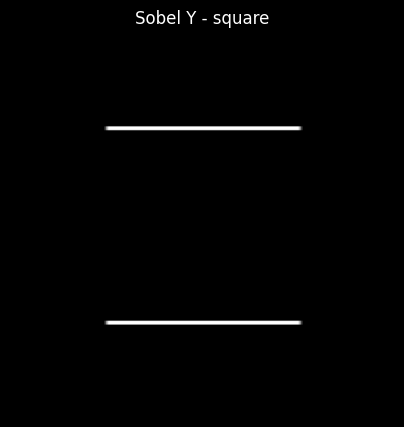

In [31]:
# Sobel in x and y directions
sobel_x = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_square, cv2.CV_64F, 0, 1, ksize=3)

show(np.abs(sobel_x), "Sobel X - square")
show(np.abs(sobel_y), "Sobel Y - square")

### Interpretation

- **Sobel X** detects changes from left to right, so it highlights **vertical edges**
- **Sobel Y** detects changes from top to bottom, so it highlights **horizontal edges**

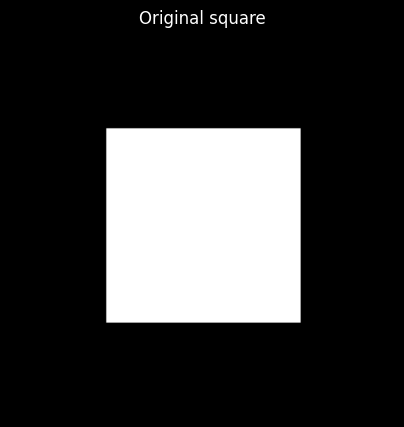

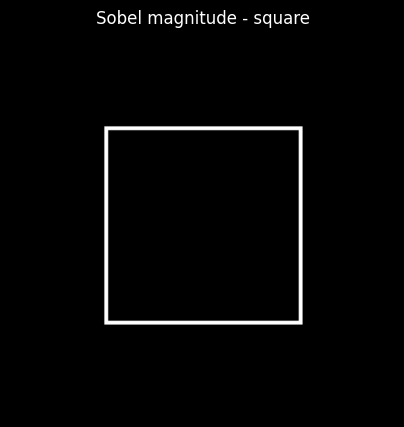

In [32]:
# Gradient magnitude from Sobel x and y
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_mag = np.clip(sobel_mag, 0, 255).astype(np.uint8)

show(img_square, "Original square")
show(sobel_mag, "Sobel magnitude - square")

### Why magnitude is useful

If we only use x or only use y, we may miss some edges.  
The magnitude combines both directions into a single image.

This usually gives a more complete edge map.

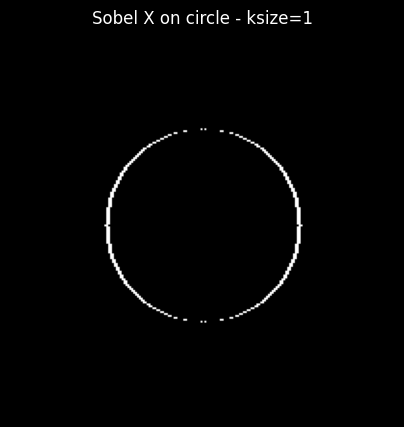

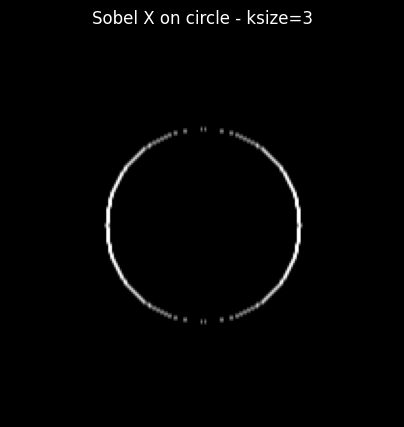

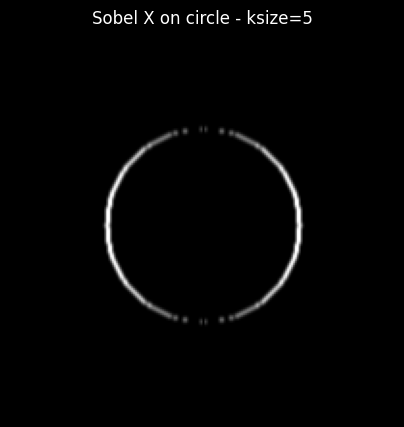

In [33]:
# Compare Sobel with different kernel sizes
for k in [1, 3, 5]:
    sobel_k = cv2.Sobel(img_circle, cv2.CV_64F, 1, 0, ksize=k)
    show(np.abs(sobel_k), f"Sobel X on circle - ksize={k}")

### What to observe

- Smaller kernels may detect finer detail.
- Larger kernels may look smoother.
- The kernel size affects sensitivity and noise behaviour.

### Student tasks — Topic 2

#### Basic tasks
1. Apply Sobel X and Sobel Y to the circle image.
2. Compare Sobel results on the square image and the circle image.
3. Change `ksize` and describe what changes visually.

#### Intermediate tasks
4. Apply Sobel to the step image and explain why the result is concentrated around one boundary.
5. Add Gaussian noise to the image and compare:
   - simple gradient
   - Sobel
6. Which method is more robust? Support your answer with visual evidence.

#### Challenging tasks
7. Create a function:
   ```python
   def sobel_edges(image, ksize=3):
       ...
   ```
   that returns `gx`, `gy`, and gradient magnitude.
8. Use your function on at least **three different images** and compare the results in a small table.
9. Explain in your own words why Sobel is often preferred over a very basic gradient kernel.
10. Try to detect only strong Sobel edges by thresholding the magnitude image. For example:
    ```python
    binary = (sobel_mag > 80).astype(np.uint8) * 255
    ```
    Test several thresholds and justify the best one.

## 4. Topic 3 — Laplacian edge detector

### Main idea

The Laplacian looks for regions where intensity changes rapidly in all directions.

Unlike Sobel:
- Sobel separates x and y directions first
- Laplacian directly uses a **second derivative**

This means Laplacian can highlight edges regardless of orientation, but it can also be more sensitive to noise.

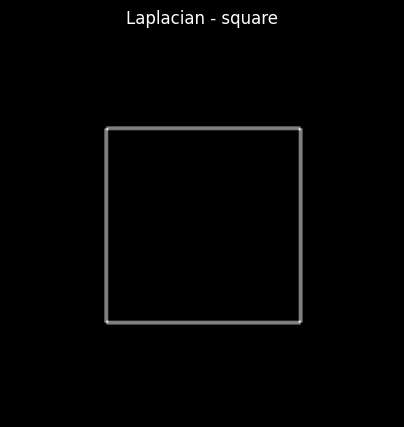

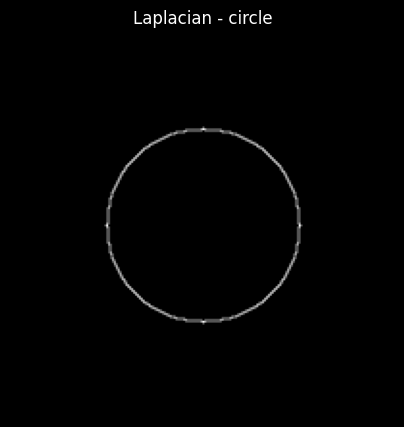

In [34]:
lap_square = cv2.Laplacian(img_square, cv2.CV_64F)
lap_circle = cv2.Laplacian(img_circle, cv2.CV_64F)

show(np.abs(lap_square), "Laplacian - square")
show(np.abs(lap_circle), "Laplacian - circle")

### Why blur before Laplacian?

Second derivatives are usually very sensitive to noise.  
So it is common to smooth the image first.

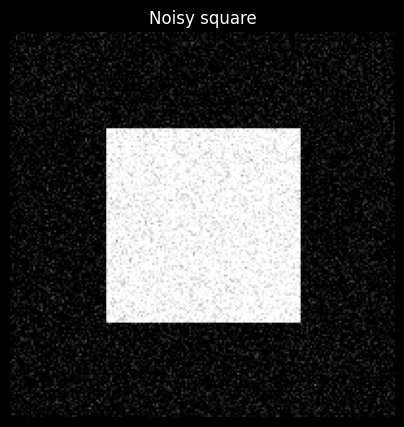

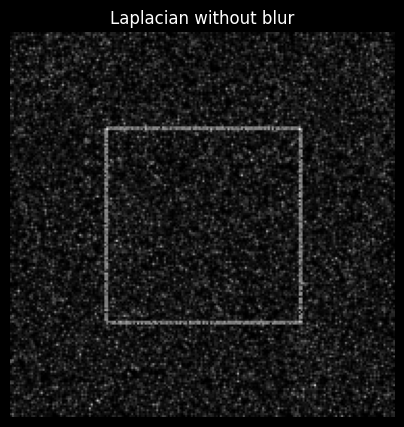

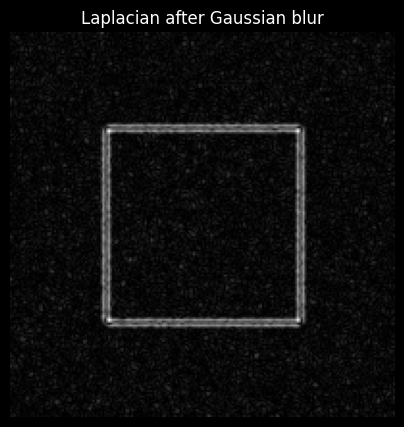

In [35]:
# Add noise to the square image
rng = np.random.default_rng(0)
noise = rng.normal(0, 25, img_square.shape)
img_square_noisy = np.clip(img_square + noise, 0, 255).astype(np.uint8)

# Laplacian without blur
lap_no_blur = cv2.Laplacian(img_square_noisy, cv2.CV_64F)

# Laplacian with Gaussian blur
img_square_blur = cv2.GaussianBlur(img_square_noisy, (5, 5), 0)
lap_blur = cv2.Laplacian(img_square_blur, cv2.CV_64F)

show(img_square_noisy, "Noisy square")
show(np.abs(lap_no_blur), "Laplacian without blur")
show(np.abs(lap_blur), "Laplacian after Gaussian blur")

### What to observe

- Without smoothing, the Laplacian reacts strongly to noise.
- After Gaussian blur, the result becomes cleaner.
- This is why preprocessing matters in edge detection.

### Student tasks — Topic 3

#### Basic tasks
1. Apply Laplacian to the step image.
2. Compare Laplacian output with Sobel magnitude on the same image.
3. Try `ksize=1` and `ksize=3` in `cv2.Laplacian`.

#### Intermediate tasks
4. Add different levels of noise and compare the Laplacian response.
5. Blur the image using kernel sizes `(3,3)`, `(5,5)`, and `(7,7)` before applying Laplacian. Which gives the best balance between clean edges and detail preservation?
6. Explain why Laplacian is more noise-sensitive than Sobel.

#### Challenging tasks
7. Create a small experiment where you measure the number of non-zero edge pixels before and after blurring.
8. Design a comparison report containing:
   - original image
   - noisy image
   - Laplacian without blur
   - Laplacian with blur
   - short interpretation
9. Research and explain the term **second derivative** in the context of images.
10. Try building a simple **Laplacian of Gaussian** pipeline manually:
    - blur the image with Gaussian filtering
    - then apply Laplacian
    - compare it with direct Laplacian

## 5. Topic 4 — Canny edge detector

### Main idea

Canny is one of the most famous edge detectors because it is usually cleaner and more practical than simple derivative methods.

Canny includes several stages:
1. noise reduction
2. gradient calculation
3. non-maximum suppression
4. double thresholding
5. edge tracking by hysteresis

So Canny is not just one filter.  
It is a full multi-step edge detection pipeline.

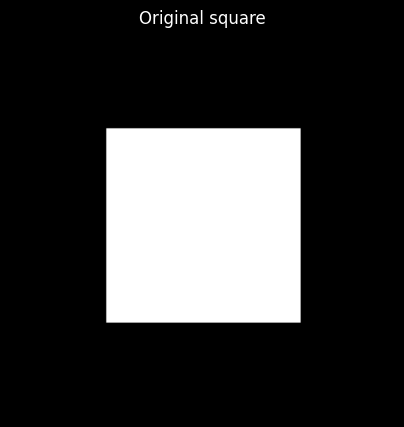

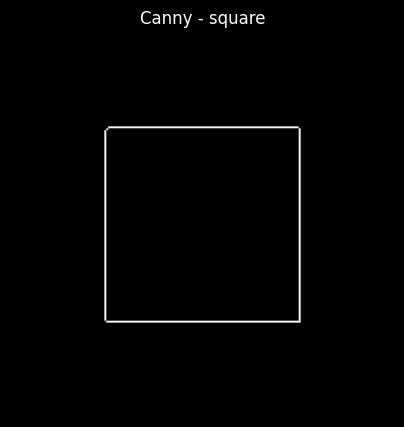

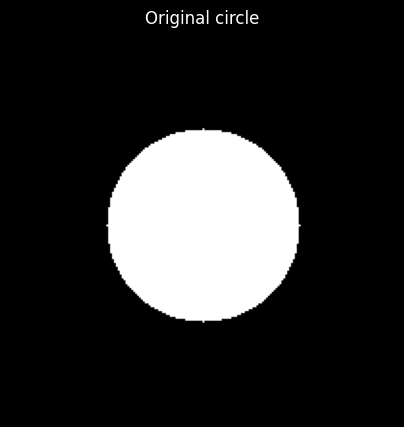

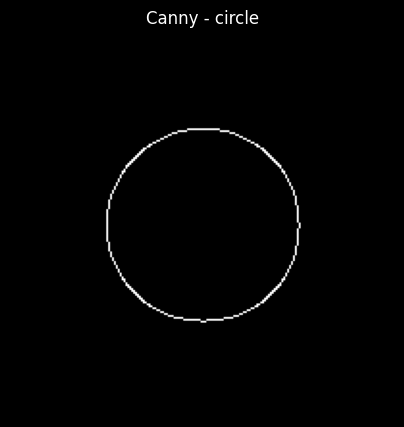

In [36]:
edges1 = cv2.Canny(img_square, 50, 150)
edges2 = cv2.Canny(img_circle, 50, 150)

show(img_square, "Original square")
show(edges1, "Canny - square")
show(img_circle, "Original circle")
show(edges2, "Canny - circle")

### Understanding the two thresholds

Canny uses:
- a **lower threshold**
- an **upper threshold**

Pixels with very strong evidence become edges immediately.  
Pixels with weaker evidence may still be kept if they are connected to strong edges.

This helps Canny produce thin and meaningful edge maps.

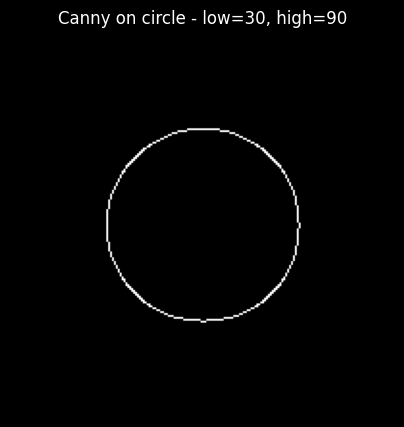

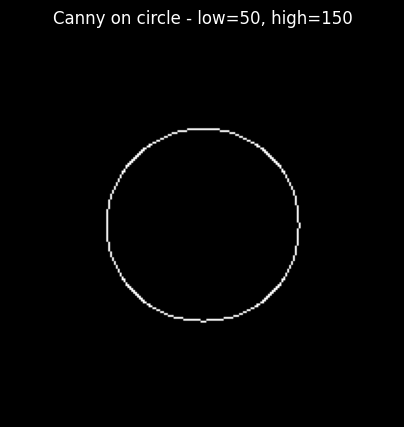

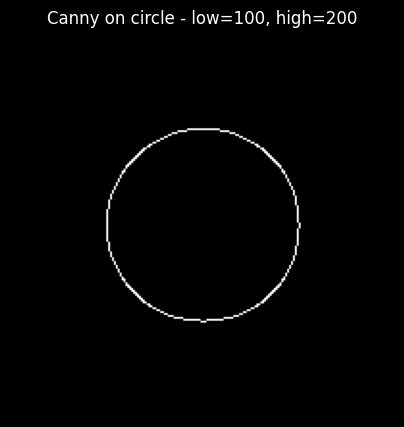

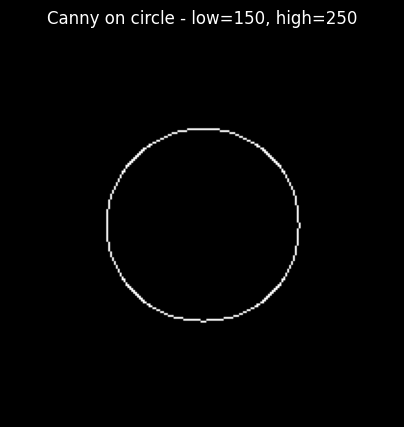

In [37]:
# Test several threshold pairs
pairs = [(30, 90), (50, 150), (100, 200), (150, 250)]

for low, high in pairs:
    edges = cv2.Canny(img_circle, low, high)
    show(edges, f"Canny on circle - low={low}, high={high}")

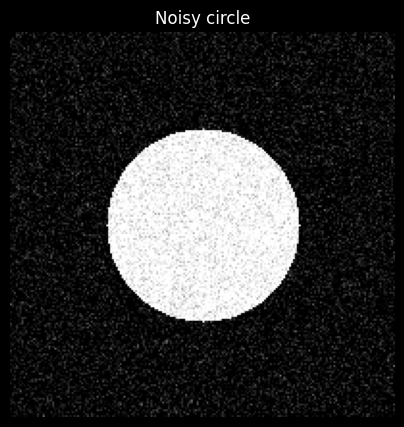

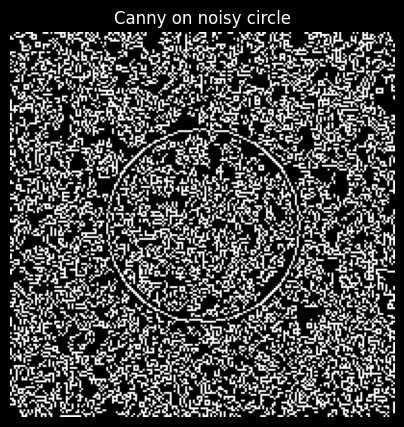

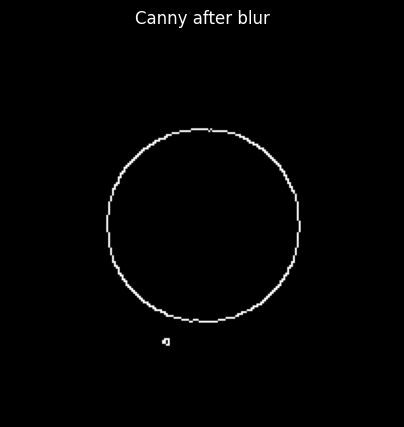

In [38]:
# Compare Canny on a noisy image
img_circle_noisy = np.clip(img_circle + rng.normal(0, 30, img_circle.shape), 0, 255).astype(np.uint8)

canny_noisy = cv2.Canny(img_circle_noisy, 50, 150)
canny_blurred = cv2.Canny(cv2.GaussianBlur(img_circle_noisy, (5, 5), 0), 50, 150)

show(img_circle_noisy, "Noisy circle")
show(canny_noisy, "Canny on noisy circle")
show(canny_blurred, "Canny after blur")

### What to observe

- Different threshold pairs produce different edge maps.
- If thresholds are too low, too many weak edges may appear.
- If thresholds are too high, important edges may disappear.
- Blurring noisy images before Canny often improves the result.

### Student tasks — Topic 4

#### Basic tasks
1. Apply Canny to the step image.
2. Try at least four different threshold pairs.
3. Decide which threshold pair gives the cleanest result for each image.

#### Intermediate tasks
4. Compare Canny with Sobel and Laplacian on the same noisy image.
5. Explain why Canny usually produces thinner edges.
6. Test the effect of Gaussian blur before Canny with different blur kernel sizes.

#### Challenging tasks
7. Build a mini experiment where you evaluate Canny using:
   - one clean image
   - one noisy image
   - one blurred image
   Summarise your observations in markdown.
8. Create a function:
   ```python
   def run_canny(image, low, high, blur=False):
       ...
   ```
   Then test it with multiple parameter values.
9. Try to find one threshold pair that works well for the square but poorly for the circle. Explain why one setting may not be universally optimal.
10. Take a real image from your own dataset and tune Canny manually for that image. Explain your final choice of thresholds.

## 6. Comparison summary

### Quick comparison

| Method | Main idea | Strength | Weakness |
|---|---|---|---|
| Simple gradient | Difference between neighbours | Easy to understand | Sensitive, limited |
| Sobel | Gradient + smoothing | More stable than basic gradient | Still may respond to noise |
| Laplacian | Second derivative | Detects edges in all directions | Very noise-sensitive |
| Canny | Multi-stage edge detector | Clean, thin, practical edges | Needs parameter tuning |

### General guidance

- Use **simple gradients** for learning the core idea.
- Use **Sobel** when directional gradient information is needed.
- Use **Laplacian** when you want orientation-independent edge response and can control noise.
- Use **Canny** when you want a strong practical baseline for edge detection.